# Testing
## Geburten nach Monat (effektives Geburtsdatum), Stadtquartier, Geschlecht und Herkunft
Datum: 14.11.2024

### Kurzbeschreibung

Anzahl Geburten nach Monat (effektives Geburtsdatum), Geschlecht, Herkunft, Stadtkreis und Stadtquartier.

Im aktuellen Jahr handelt es sich um provisorische Daten. Diese können laufend korrigiert werden. Erst mit dem Jahresabschluss werden die Daten definitiv.

Es ist möglich, dass eine Geburt z.B. vom 28. Dezember 2020 erst Ende Januar 2021, also nach dem Jahresabschluss von Statistik Stadt Zürich, gemeldet wurde. Im vorliegenden Datensatz wird das effektive Geburtsdatum (28. Dezember 2020) und nicht das korrigierte (1. Januar 2021) verwendet. Daher können die vorliegenden Daten von den anderen Daten von Statistik Stadt Zürich abweichen



Dataset auf PROD-Datakatalog: Link https://data.stadt-zuerich.ch/dataset/bev_monat_effektiv_geburten_quartier_geschl_ag_herkunft_od4081

Dataset auf INTEG-Datakatalog: Link https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_monat_effektiv_geburten_quartier_geschl_ag_herkunft_od4081

### Importiere die notwendigen Packages

In [1]:
#%pip install altair folium geopandas matplotlib numpy pandas plotly requests seaborn

In [2]:
import altair as alt
import datetime
import folium 
import geopandas as gpd
import io
from IPython.display import Markdown as md
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
#import pivottablejs
#from pivottablejs import pivot_ui
import plotly.express as px
import requests
import seaborn as sns

Importiere die eigenen Funktionen, die unter ../0_scripts abegelegt sind:

In [3]:
import sys
sys.path.append('../0_scripts')

import my_py_dataviz_functions as mypy_dv
import my_py_dataloading_functions as mypy_dl

In [4]:
SSL_VERIFY = False
# evtl. SSL_VERIFY auf False setzen wenn die Verbindung zu https://www.gemeinderat-zuerich.ch nicht klappt (z.B. wegen Proxy)
# Um die SSL Verifikation auszustellen, bitte die nächste Zeile einkommentieren ("#" entfernen)
# SSL_VERIFY = False

In [5]:
if not SSL_VERIFY:
    import urllib3
    urllib3.disable_warnings()

### Settings
Definiere Settings. 
Hier das Zahlenformat von Float-Werten (z.B. *'{:,.2f}'.format* mit Komma als Tausenderzeichen)

In [6]:
#pd.options.display.float_format = lambda x : '{:,.1f}'.format(x) if (np.isnan(x) | np.isinf(x)) else '{:,.0f}'.format(x) if int(x) == x else '{:,.1f}'.format(x)
pd.options.display.float_format = '{:.0f}'.format
pd.set_option('display.width', 100)
pd.set_option('display.max_columns', 15)

#### Zeitvariabeln


In [7]:
#Zeitvariabeln als Strings:
now = datetime.date.today()
year_today = now.strftime("%Y")
date_today = "_"+now.strftime("%Y-%m-%d")

#Zeitvariabeln als Integers:
int_times = now.timetuple()
aktuellesJahr = int_times[0]
aktuellerMonat = int_times[1]
selectedMonat = int_times[1]-2
#print(aktuellesJahr, aktuellerMonat,'datenstand: ', selectedMonat, int_times)

### Daten importieren und Metadaten checken

- status: int / prod
- data_source: web / ld / dropzone
- datums_attr: beschreibt das oder die Datumsfelder, die als Datum geparsed werden sollen. Falls es keines gibt: None

In [8]:
package_name = "bev_monat_effektiv_geburten_quartier_geschl_ag_herkunft_od4081"

In [9]:
data2betested = mypy_dl.load_data(
    status = 'int'
    , data_source = 'web'
    , package_name = package_name
    , dataset_name = "BEV408OD4081"    
    , datums_attr = ['GueltigAbDatJahr','StichtagDat']
    )

fp lautet:https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_monat_effektiv_geburten_quartier_geschl_ag_herkunft_od4081/download/BEV408OD4081.csv


 **Überprüfe die Metadaten:**

 **Dataset auf INTEG-Datakatalog:** Link https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_monat_effektiv_geburten_quartier_geschl_ag_herkunft_od4081 

 **Dataset auf PROD-Datakatalog:** Link https://data.stadt-zuerich.ch/dataset/bev_monat_effektiv_geburten_quartier_geschl_ag_herkunft_od4081 

Es ist ein Fehler aufgetreten: Missing column provided to 'parse_dates': 'GueltigAbDatJahr, StichtagDat'


Error: Missing column provided to 'parse_dates': 'GueltigAbDatJahr, StichtagDat'



In [10]:
data2betested.tail(2).T

AttributeError: 'NoneType' object has no attribute 'tail'

Berechne weitere Attribute falls notwendig

In [ ]:
data2betested = (
    data2betested
    .copy()
    .assign(
        #Aktualisierungs_Datum_str= lambda x: x.Aktualisierungs_Datum.astype(str),
        StichtagDat_str = lambda x: x.StichtagDat.astype(str),
        Jahr = lambda x: x.GueltigAbDatJahr,
        Jahr_nbr = lambda x: x.Jahr.dt.year,
    )
    .sort_values('StichtagDat', ascending=False)
    )
data2betested.dtypes

GueltigAbDatJahr        datetime64[ns]
GueltigAbDatMM                   int64
GueltigAbDatMonat               object
StichtagDat             datetime64[ns]
SexCd                            int64
SexLang                         object
HerkunftCd                       int64
HerkunftLang                    object
KreisCd                          int64
KreisLang                       object
QuarCd                           int64
QuarLang                        object
DatenstandCd                    object
DatenstandLang                  object
LebensfaehigkeitCd              object
LebensfaehigkeitLang            object
AnzGebuWir                       int64
StichtagDat_str                 object
Jahr                    datetime64[ns]
Jahr_nbr                         int32
dtype: object

Minimales und maximales Jahr im Datensatz

In [ ]:
data_max_date = max(data2betested.StichtagDat).strftime('%Y-%m-%d')
data_min_date = min(data2betested.StichtagDat).strftime('%Y-%m-%d')


print(f"Die Daten haben ein Minimumjahr von {data_min_date} und ein Maximumjahr von {data_max_date}")

Die Daten haben ein Minimumjahr von 1998-01-31 und ein Maximumjahr von 2025-10-31


### Einfache Datentests

In [ ]:
data2betested.sort_values('StichtagDat', ascending=False).head(2).T

,34879,34869
GueltigAbDatJahr,2025-01-01 00:00:00,2025-01-01 00:00:00
GueltigAbDatMM,10,10
GueltigAbDatMonat,Oktober,Oktober
StichtagDat,2025-10-31 00:00:00,2025-10-31 00:00:00
SexCd,2,2
SexLang,weiblich,weiblich
HerkunftCd,2,2
HerkunftLang,Ausländer*in,Ausländer*in
KreisCd,99,6
KreisLang,Unbekannt (Stadt Zürich),Kreis 6


In [ ]:
#data2betested.dtypes
data2betested.info(memory_usage='deep', verbose=True)

<class 'pandas.core.frame.DataFrame'>
Index: 34880 entries, 34879 to 0
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   GueltigAbDatJahr      34880 non-null  datetime64[ns]
 1   GueltigAbDatMM        34880 non-null  int64         
 2   GueltigAbDatMonat     34880 non-null  object        
 3   StichtagDat           34880 non-null  datetime64[ns]
 4   SexCd                 34880 non-null  int64         
 5   SexLang               34880 non-null  object        
 6   HerkunftCd            34880 non-null  int64         
 7   HerkunftLang          34880 non-null  object        
 8   KreisCd               34880 non-null  int64         
 9   KreisLang             34880 non-null  object        
 10  QuarCd                34880 non-null  int64         
 11  QuarLang              34880 non-null  object        
 12  DatenstandCd          34880 non-null  object        
 13  DatenstandLang       

In [ ]:
print(f'The dataset has {data2betested.shape[0]:,.0f} rows (observations) and {data2betested.shape[1]:,.0f} columns (variables).')
print(f'There seem to be {data2betested.duplicated().sum()} exact duplicates in the data.')

The dataset has 34,880 rows (observations) and 20 columns (variables).
There seem to be 0 exact duplicates in the data.


In [ ]:
data2betested.describe()

,GueltigAbDatJahr,GueltigAbDatMM,StichtagDat,SexCd,HerkunftCd,KreisCd,QuarCd,AnzGebuWir,Jahr,Jahr_nbr
count,34880,34880,34880,34880,34880,34880,34880,34880,34880,34880
mean,2011-09-27 12:21:15.688073216,6,2012-04-10 14:25:19.266054912,1,1,7,72,4,2011-09-27 12:21:15.688073216,2012
min,1998-01-01 00:00:00,1,1998-01-31 00:00:00,1,1,1,11,1,1998-01-01 00:00:00,1998
25%,2005-01-01 00:00:00,4,2005-05-31 00:00:00,1,1,4,42,1,2005-01-01 00:00:00,2005
50%,2012-01-01 00:00:00,7,2012-06-30 00:00:00,1,1,7,72,3,2012-01-01 00:00:00,2012
75%,2019-01-01 00:00:00,9,2019-02-28 00:00:00,2,2,10,102,5,2019-01-01 00:00:00,2019
max,2025-01-01 00:00:00,12,2025-10-31 00:00:00,2,2,99,999,22,2025-01-01 00:00:00,2025
std,NaN,3,NaN,0,0,4,38,3,NaN,8


Welches sind die Quartiere ohne Werte bei BEW?

In [ ]:
data2betested[np.isnan(data2betested.AnzGebuWir)]

,GueltigAbDatJahr,GueltigAbDatMM,GueltigAbDatMonat,StichtagDat,SexCd,SexLang,HerkunftCd,...,DatenstandLang,LebensfaehigkeitCd,LebensfaehigkeitLang,AnzGebuWir,StichtagDat_str,Jahr,Jahr_nbr


### Verwende das Datum als Index

While we did already parse the `datetime` column into the respective datetime type, it currently is just a regular column. 
**To enable quick and convenient queries and aggregations, we need to turn it into the index of the DataFrame**

In [ ]:
data2betested = data2betested.set_index("StichtagDat")
data2betested = data2betested.sort_index()

In [ ]:
data2betested.index.year.unique()

Index([1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012,
       2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025],
      dtype='int32', name='StichtagDat')

### Beschreibe einzelne Attribute

Beschreibe nicht numerische Attribute

In [ ]:
# describe non-numerical features
try:
    with pd.option_context('display.float_format', '{:,.2f}'.format):
        display(data2betested.describe(exclude='number',datetime_is_numeric=True))
except:
    print("No categorical data in dataset.")

No categorical data in dataset.


Beschreibe numerische Attribute

In [ ]:
# describe numerical features
try:
    with pd.option_context('display.float_format', '{:,.0f}'.format):
        display(data2betested.describe(include='number'))
except:
    print("No numercial data in dataset.")

,GueltigAbDatMM,SexCd,HerkunftCd,KreisCd,QuarCd,AnzGebuWir,Jahr_nbr
count,"34,880","34,880","34,880","34,880","34,880","34,880","34,880"
mean,6,1,1,7,72,4,"2,012"
std,3,0,0,4,38,3,8
min,1,1,1,1,11,1,"1,998"
25%,4,1,1,4,42,1,"2,005"
50%,7,1,1,7,72,3,"2,012"
75%,9,2,2,10,102,5,"2,019"
max,12,2,2,99,999,22,"2,025"


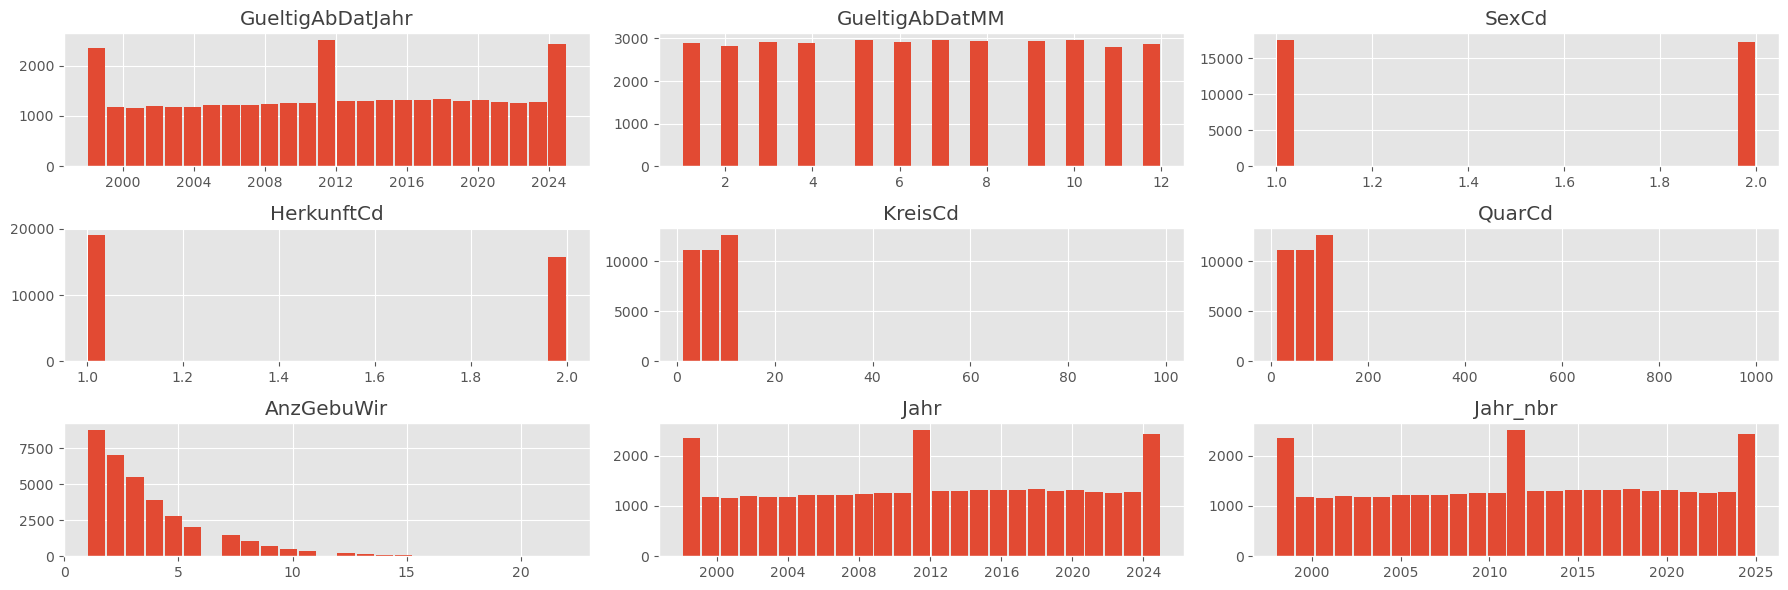

In [ ]:
plt.style.use('ggplot')
params = {
    'text.color': (0.25, 0.25, 0.25),
    'figure.figsize': [18, 6],
   }
plt.rcParams.update(params)

try:
    data2betested.hist(bins=25, rwidth=0.9)
    plt.tight_layout()
    plt.show()
except:
    print("No numercial data to plot.") 

### Gibt es Duplikate?

In [ ]:
# find duplicate rows
duplicate_rows = data2betested[data2betested.duplicated()]
duplicate_rows

,GueltigAbDatJahr,GueltigAbDatMM,GueltigAbDatMonat,SexCd,SexLang,HerkunftCd,HerkunftLang,...,DatenstandLang,LebensfaehigkeitCd,LebensfaehigkeitLang,AnzGebuWir,StichtagDat_str,Jahr,Jahr_nbr
StichtagDat,,,,,,,,,,,,,,,


### Nullwerte und Missings?

In [ ]:
data2betested.isnull().sum()

GueltigAbDatJahr        0
GueltigAbDatMM          0
GueltigAbDatMonat       0
SexCd                   0
SexLang                 0
HerkunftCd              0
HerkunftLang            0
KreisCd                 0
KreisLang               0
QuarCd                  0
QuarLang                0
DatenstandCd            0
DatenstandLang          0
LebensfaehigkeitCd      0
LebensfaehigkeitLang    0
AnzGebuWir              0
StichtagDat_str         0
Jahr                    0
Jahr_nbr                0
dtype: int64

In [ ]:
# check missing values with missingno
# https://github.com/ResidentMario/missingno
#import missingno as msno
#msno.matrix(data2betested, labels=True, sort='descending');
#msno.heatmap(data2betested)

### Gruppierungen

In [ ]:
agg_jahr = data2betested.loc[data_min_date:data_max_date].reset_index()\
    .groupby(['StichtagDat', 'GueltigAbDatMonat', 'Jahr_nbr']) \
    .agg(sum_AnzBestWir=('AnzGebuWir', 'sum')) \
    .sort_values('StichtagDat', ascending=False) 
agg_jahr.reset_index().head(6)

,StichtagDat,GueltigAbDatMonat,Jahr_nbr,sum_AnzBestWir
0,2025-10-31,Oktober,2025,340
1,2025-09-30,September,2025,343
2,2025-08-31,August,2025,388
3,2025-07-31,Juli,2025,386
4,2025-06-30,Juni,2025,397
5,2025-05-31,Mai,2025,402


In [ ]:
agg_herk = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['HerkunftCd', 'HerkunftLang']) \
    .agg(sum_AnzBestWir=('AnzGebuWir', 'sum')) \
    .sort_values('HerkunftCd', ascending=False) 
agg_herk.reset_index().head(3)

,HerkunftCd,HerkunftLang,sum_AnzBestWir
0,2,Ausländer*in,43296
1,1,Schweizer*in,80357


In [ ]:
agg_lf = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['StichtagDat','LebensfaehigkeitCd', 'LebensfaehigkeitLang']) \
    .agg(sum_AnzBestWir=('AnzGebuWir', 'sum')) \
    .sort_values('StichtagDat', ascending=False) 
agg_lf.reset_index().head(3)

,StichtagDat,LebensfaehigkeitCd,LebensfaehigkeitLang,sum_AnzBestWir
0,2025-10-31,J,zutreffend,340
1,2025-09-30,J,zutreffend,343
2,2025-08-31,J,zutreffend,388


In [ ]:
agg_kreis_quart = data2betested.loc[data_max_date]\
    .groupby(['StichtagDat','KreisCd', 'KreisLang', 'QuarCd', 'QuarLang']) \
    .agg(sum_AnzBestWir=('AnzGebuWir', 'sum')) \
    .sort_values('QuarCd', ascending=False) 
agg_kreis_quart.reset_index().head(6)

,StichtagDat,KreisCd,KreisLang,QuarCd,QuarLang,sum_AnzBestWir
0,2025-10-31,99,Unbekannt (Stadt Zürich),999,Unbekannt (Stadt Zürich),1
1,2025-10-31,12,Kreis 12,123,Hirzenbach,9
2,2025-10-31,12,Kreis 12,122,Schwamendingen-Mitte,7
3,2025-10-31,12,Kreis 12,121,Saatlen,6
4,2025-10-31,11,Kreis 11,119,Seebach,20
5,2025-10-31,11,Kreis 11,115,Oerlikon,16


In [ ]:
agg_dstand = data2betested.loc["2023-01":data_max_date]\
    .groupby(['StichtagDat','DatenstandCd','DatenstandLang']) \
    .agg(sum_AnzBestWir=('AnzGebuWir', 'sum')) \
    .sort_values('StichtagDat', ascending=False) 
agg_dstand.reset_index().head(4)

,StichtagDat,DatenstandCd,DatenstandLang,sum_AnzBestWir
0,2025-10-31,P,Provisorisch,340
1,2025-09-30,P,Provisorisch,343
2,2025-08-31,P,Provisorisch,388
3,2025-07-31,P,Provisorisch,386


In [ ]:
data2betested.columns

Index(['GueltigAbDatJahr', 'GueltigAbDatMM', 'GueltigAbDatMonat', 'SexCd', 'SexLang', 'HerkunftCd',
       'HerkunftLang', 'KreisCd', 'KreisLang', 'QuarCd', 'QuarLang', 'DatenstandCd',
       'DatenstandLang', 'LebensfaehigkeitCd', 'LebensfaehigkeitLang', 'AnzGebuWir',
       'StichtagDat_str', 'Jahr', 'Jahr_nbr'],
      dtype='object')

### Visualisierungen nach Zeitausschnitten

In [ ]:
data2betested.columns
#data2betested

Index(['GueltigAbDatJahr', 'GueltigAbDatMM', 'GueltigAbDatMonat', 'SexCd', 'SexLang', 'HerkunftCd',
       'HerkunftLang', 'KreisCd', 'KreisLang', 'QuarCd', 'QuarLang', 'DatenstandCd',
       'DatenstandLang', 'LebensfaehigkeitCd', 'LebensfaehigkeitLang', 'AnzGebuWir',
       'StichtagDat_str', 'Jahr', 'Jahr_nbr'],
      dtype='object')

#### Entwicklung Geburten nach Stadtkreis

In [ ]:

myAgg1 = data2betested.loc[data_min_date:data_max_date] \
    .groupby(['StichtagDat','GueltigAbDatJahr', 'GueltigAbDatMM', 'GueltigAbDatMonat','Jahr_nbr','KreisCd', 'KreisLang']) \
    .agg(sum_WBev=('AnzGebuWir', 'sum')) \
    .sort_values('sum_WBev', ascending=True)  

myAgg1.reset_index().sort_values('StichtagDat', ascending=False).head(4)

,StichtagDat,GueltigAbDatJahr,GueltigAbDatMM,GueltigAbDatMonat,Jahr_nbr,KreisCd,KreisLang,sum_WBev
0,2025-10-31,2025-01-01,10,Oktober,2025,99,Unbekannt (Stadt Zürich),1
1233,2025-10-31,2025-01-01,10,Oktober,2025,12,Kreis 12,22
2088,2025-10-31,2025-01-01,10,Oktober,2025,10,Kreis 10,30
2374,2025-10-31,2025-01-01,10,Oktober,2025,6,Kreis 6,33


In [ ]:
grafik1 = mypy_dv.plot_altair_multiline_highlight(
    data = myAgg1.reset_index().query('Jahr_nbr>2014').sort_values('KreisCd', ascending=True)
    ,x = 'StichtagDat:T'
    ,y = 'sum_WBev:Q'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = 'Anz. Babies'
    ,category = "KreisLang:N"
    ,category_beschriftung= 'Legende:'
    ,warning_status = "ignore" #always or ignore
    ,myTitle="Geburten nach Monat und Stadtkreis, seit "+data_min_date
)
grafik1

alt.LayerChart(...)

#### Entwicklung nach Geschlecht

In [ ]:
data2betested.dtypes
data2betested.head(2)

,GueltigAbDatJahr,GueltigAbDatMM,GueltigAbDatMonat,SexCd,SexLang,HerkunftCd,HerkunftLang,...,DatenstandLang,LebensfaehigkeitCd,LebensfaehigkeitLang,AnzGebuWir,StichtagDat_str,Jahr,Jahr_nbr
StichtagDat,,,,,,,,,,,,,,,
1998-01-31,1998-01-01,1,Januar,1,männlich,1,Schweizer*in,...,Veröffentlicht,J,zutreffend,4,1998-01-31,1998-01-01,1998
1998-01-31,1998-01-01,1,Januar,1,männlich,1,Schweizer*in,...,Veröffentlicht,J,zutreffend,3,1998-01-31,1998-01-01,1998


In [ ]:
#myAgg = data2betested.loc[five_years_ago:latest_year] \
myAgg2 = data2betested \
    .groupby(['StichtagDat','GueltigAbDatJahr', 'GueltigAbDatMM', 'SexLang']) \
    .agg(sum_WBev=('AnzGebuWir', 'sum')) \
    .sort_values('StichtagDat', ascending=False)

myAgg2.reset_index().head(4)

,StichtagDat,GueltigAbDatJahr,GueltigAbDatMM,SexLang,sum_WBev
0,2025-10-31,2025-01-01,10,weiblich,166
1,2025-10-31,2025-01-01,10,männlich,174
2,2025-09-30,2025-01-01,9,weiblich,166
3,2025-09-30,2025-01-01,9,männlich,177


In [ ]:
grafik2 = mypy_dv.plot_altair_multiline_highlight(
    data = myAgg2.reset_index().query('sum_WBev>100')
    ,x = 'StichtagDat:T'
    ,y = 'sum_WBev:Q'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = 'Anz. Personen'
    ,category = "SexLang:N"
    ,category_beschriftung= 'Legende:'
    ,warning_status = "ignore" #always or ignore
    ,myTitle="Geburten nach Geschlecht, seit "+data_min_date +" (effektives Geburtsdatum)"
)
grafik2

alt.LayerChart(...)

#### Entwicklung nach Heimat

In [ ]:
#myAgg = data2betested.loc["2008-11":"2021-11"] \
myAgg3 = data2betested \
    .groupby(['StichtagDat','GueltigAbDatJahr', 'GueltigAbDatMM', 'HerkunftLang']) \
    .agg(sum_WBev=('AnzGebuWir', 'sum')) \
    .sort_values('sum_WBev', ascending=False)
myAgg3.reset_index().head(2)

,StichtagDat,GueltigAbDatJahr,GueltigAbDatMM,HerkunftLang,sum_WBev
0,2021-08-31,2021-01-01,8,Schweizer*in,339
1,2021-07-31,2021-01-01,7,Schweizer*in,327


In [ ]:
grafik3 = mypy_dv.plot_altair_multiline_highlight(
    data = myAgg3.reset_index().query('sum_WBev>10')
    ,x = 'StichtagDat:T'
    ,y = 'sum_WBev:Q'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = 'Anz. Personen'
    ,category = "HerkunftLang:N"
    ,category_beschriftung= 'Legende:'
    ,warning_status = "ignore" #always or ignore
    ,myTitle="Geburten nach Herkunft, seit "+data_min_date +" (effektives Geburtsdatum)"
)
grafik3

alt.LayerChart(...)

### Radarplot

#### Geburten nach Geburtsmonat

Da es sehr viele Jahre gibt, kannst Du hier das Minimumjahr bestimmen.

In [ ]:
manuelles_min_jahr = "2012-01"

In [ ]:
myAggX = data2betested.loc[manuelles_min_jahr:data_max_date]  \
    .groupby(['StichtagDat','GueltigAbDatJahr','Jahr_nbr', 'GueltigAbDatMM']) \
    .agg(sum_WBev=('AnzGebuWir', 'sum')) \
    .sort_values('sum_WBev', ascending=False) 

myAggX.reset_index().sort_values('StichtagDat',ascending=False).head(5)

,StichtagDat,GueltigAbDatJahr,Jahr_nbr,GueltigAbDatMM,sum_WBev
159,2025-10-31,2025-01-01,2025,10,340
157,2025-09-30,2025-01-01,2025,9,343
120,2025-08-31,2025-01-01,2025,8,388
122,2025-07-31,2025-01-01,2025,7,386
110,2025-06-30,2025-01-01,2025,6,397


Daten vorbereiten für Radarplot

In [ ]:
import calendar

# Monatsnamen erstellen
month_names = [calendar.month_abbr[i] for i in range(1, 13)]

# DataFrame vorbereiten
df = myAggX.reset_index()

# Monatszahlen in Monatsnamen umwandeln und eine numerische Monatsspalte hinzufügen
df['MonthName'] = df['GueltigAbDatMM'].apply(lambda x: calendar.month_abbr[x])
df['MonthNum'] = df['GueltigAbDatMM']

# Sortieren Sie den DataFrame nach Jahr und Monat
df = df.sort_values(['Jahr_nbr', 'MonthNum'])

# Erstelle separate DataFrames für jedes Jahr und füge fehlende Monate hinzu
years = df['Jahr_nbr'].unique()
dfs = []

for year in years:
    year_df = df[df['Jahr_nbr'] == year].copy()
    
    # Fügen Sie fehlende Monate hinzu
    for month in range(1, 13):
        if month not in year_df['MonthNum'].values:
            new_row = pd.DataFrame({'Jahr_nbr': [year], 'MonthNum': [month], 'MonthName': [calendar.month_abbr[month]], 'sum_WBev': [0]})
            year_df = pd.concat([year_df, new_row], ignore_index=True)
    
    year_df = year_df.sort_values('MonthNum')
    dfs.append(year_df)

# Kombiniere alle DataFrames wieder
df_final = pd.concat(dfs, ignore_index=True)

In [ ]:
df_final

,StichtagDat,GueltigAbDatJahr,Jahr_nbr,GueltigAbDatMM,sum_WBev,MonthName,MonthNum
0,2012-01-31,2012-01-01,2012,1,380,Jan,1
1,2012-02-29,2012-01-01,2012,2,348,Feb,2
2,2012-03-31,2012-01-01,2012,3,368,Mar,3
3,2012-04-30,2012-01-01,2012,4,414,Apr,4
4,2012-05-31,2012-01-01,2012,5,397,May,5
...,...,...,...,...,...,...,...
163,2025-08-31,2025-01-01,2025,8,388,Aug,8
164,2025-09-30,2025-01-01,2025,9,343,Sep,9
165,2025-10-31,2025-01-01,2025,10,340,Oct,10
166,NaT,NaT,2025,NaN,0,Nov,11


In [ ]:
num_years = len(years)
print(num_years)

# Erstellen Sie eine benutzerdefinierte Farbpalette mit 20 Farben
#color_scale = px.colors.qualitative.Light24[:num_years]
color_scale = px.colors.sequential.Turbo[:num_years] # viridis, magma, inferno, Plasma, Cividis, Plotly3, Turbo

# Erstellen Sie ein Wörterbuch, das jedes Jahr einer Farbe zuordnet
color_map = dict(zip(sorted(years, reverse=True), color_scale))
print(color_map)

# Radarplot erstellen
fig = px.line_polar(df_final, r="sum_WBev", theta="MonthName", color="Jahr_nbr", 
                    line_close=True,
                    #color_discrete_sequence=px.colors.sequential.Plasma_r,
                    #color_discrete_sequence=color_scale,
                    color_discrete_map=color_map,
                    template="seaborn",
                    category_orders={"MonthName": month_names})

# Layout anpassen
fig.update_layout(
    polar=dict(
        radialaxis=dict(showticklabels=True, ticks=''),
        angularaxis=dict(direction="clockwise", period=12)
    ),
    legend_title_text='Jahr:'
)

fig.show()

14
{2025: '#30123b', 2024: '#4145ab', 2023: '#4675ed', 2022: '#39a2fc', 2021: '#1bcfd4', 2020: '#24eca6', 2019: '#61fc6c', 2018: '#a4fc3b', 2017: '#d1e834', 2016: '#f3c63a', 2015: '#fe9b2d', 2014: '#f36315', 2013: '#d93806', 2012: '#b11901'}


### Animierter Radarplot pro Monat

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import calendar


# Angenommen, df_final ist Ihr vorbereiteter DataFrame

# Funktion zum Erweitern der Daten für ein vollständiges Jahr
def extend_year_data(year_data):
    first_month = year_data.iloc[0].copy()
    first_month['MonthNum'] = 13
    first_month['MonthName'] = year_data.iloc[0]['MonthName']
    return pd.concat([year_data, pd.DataFrame([first_month])]).sort_values('MonthNum')

# Jahre und Farbskala vorbereiten
years = sorted(df_final['Jahr_nbr'].unique())
num_years = len(years)
color_scale = px.colors.sequential.Turbo[:num_years][::-1]

# Farbzuordnung erstellen
color_map = dict(zip(years, color_scale))

# Erstellen Sie eine Figure mit einem polaren Subplot
fig = make_subplots(rows=1, cols=1, specs=[[{'type': 'polar'}]])

# Fügen Sie für jedes Jahr eine Linie hinzu
for year in years:
    year_data = df_final[df_final['Jahr_nbr'] == year].sort_values('MonthNum')
    year_data = extend_year_data(year_data)
    fig.add_trace(go.Scatterpolar(
        r=year_data['sum_WBev'],
        theta=year_data['MonthName'],
        mode='lines',
        name=str(year),
        line=dict(color=color_map[year]),
        showlegend=True,
        visible=False  # Anfangs alle unsichtbar
    ))

# Erstellen Sie Frames für die Animation
frames = []
for year in years:
    for month in range(1, 14):  # Erweitert auf 13 Monate
        month_name = calendar.month_abbr[month % 12 or 12]
        frame_data = []
        for y in years:
            year_data = df_final[df_final['Jahr_nbr'] == y].sort_values('MonthNum')
            year_data = extend_year_data(year_data)
            if y <= year:
                display_months = 13 if y < year else month
                frame_data.append(go.Scatterpolar(
                    r=year_data['sum_WBev'][:display_months],
                    theta=year_data['MonthName'][:display_months],
                    mode='lines',
                    name=str(y),
                    line=dict(color=color_map[y]),
                    showlegend=True,
                    visible=True
                ))
            else:
                frame_data.append(go.Scatterpolar(visible=False))
        frame = go.Frame(data=frame_data, name=f"{year}-{month_name}")
        frames.append(frame)

# Fügen Sie die Frames zur Figure hinzu
fig.frames = frames

# Layout anpassen
fig.update_layout(
    title={
        'text': "Geburten in der Stadt Zürich nach Monat",
        'y':0.95,
        'x':0.5,
        'xanchor': 'center',
        'yanchor': 'top',
        'font': dict(
            family="Arial, sans-serif",
            size=24,
            color="black"
        )
    },
    height=700,
    polar=dict(
        radialaxis=dict(showticklabels=True, ticks='', range=[0, df_final['sum_WBev'].max()]),
        angularaxis=dict(direction="clockwise", period=12)
    ),
    updatemenus=[{
        "buttons": [
            {
                "args": [None, {"frame": {"duration": 200, "redraw": True},
                                "fromcurrent": True, "transition": {"duration": 100,
                                                                    "easing": "quadratic-in-out"}}],
                "label": "Play",
                "method": "animate"
            },
            {
                "args": [[None], {"frame": {"duration": 0, "redraw": True},
                                  "mode": "immediate",
                                  "transition": {"duration": 0}}],
                "label": "Pause",
                "method": "animate"
            }
        ],
        "direction": "left",
        "pad": {"r": 10, "t": 87},
        "showactive": False,
        "type": "buttons",
        "x": 0.1,
        "xanchor": "right",
        "y": 0,
        "yanchor": "top"
    }],
    sliders=[{
        "active": 0,
        "yanchor": "top",
        "xanchor": "left",
        "currentvalue": {
            "font": {"size": 20},
            "prefix": "Datum: ",
            "visible": True,
            "xanchor": "right"
        },
        "transition": {"duration": 100, "easing": "cubic-in-out"},
        "pad": {"b": 10, "t": 50},
        "len": 0.9,
        "x": 0.1,
        "y": 0,
        "steps": [
            {
                "args": [[f"{year}-{calendar.month_abbr[month % 12 or 12]}"], {"frame": {"duration": 100, "redraw": True},
                                   "mode": "immediate",
                                   "transition": {"duration": 100}}],
                "label": f"{year}-{calendar.month_abbr[month % 12 or 12]}",
                "method": "animate"
            } for year in years for month in range(1, 14)  # Erweitert auf 13 Monate
        ]
    }],
    showlegend=True,
    legend_title_text='Jahr:',
    template="plotly"
)

fig.show()

### Faced Grids

In [ ]:
sns.set_theme(style="whitegrid")

In [ ]:
data2betested.reset_index().columns

Index(['StichtagDat', 'GueltigAbDatJahr', 'GueltigAbDatMM', 'GueltigAbDatMonat', 'SexCd',
       'SexLang', 'HerkunftCd', 'HerkunftLang', 'KreisCd', 'KreisLang', 'QuarCd', 'QuarLang',
       'DatenstandCd', 'DatenstandLang', 'LebensfaehigkeitCd', 'LebensfaehigkeitLang',
       'AnzGebuWir', 'StichtagDat_str', 'Jahr', 'Jahr_nbr'],
      dtype='object')

In [ ]:
#.query('HerkunftLang !="Ausland"')
myFG = data2betested\
    .groupby(['StichtagDat', 'Jahr_nbr', 'HerkunftCd', 'HerkunftLang', 'KreisCd', 'KreisLang', 'QuarCd', 'QuarLang',]) \
    .agg(sum_WGeb=('AnzGebuWir', 'sum')) \
    .sort_values('QuarCd', ascending=True) 
myFG.reset_index().head(2)

,StichtagDat,Jahr_nbr,HerkunftCd,HerkunftLang,KreisCd,KreisLang,QuarCd,QuarLang,sum_WGeb
0,2003-05-31,2003,1,Schweizer*in,1,Kreis 1,11,Rathaus,3
1,2011-06-30,2011,1,Schweizer*in,1,Kreis 1,11,Rathaus,4


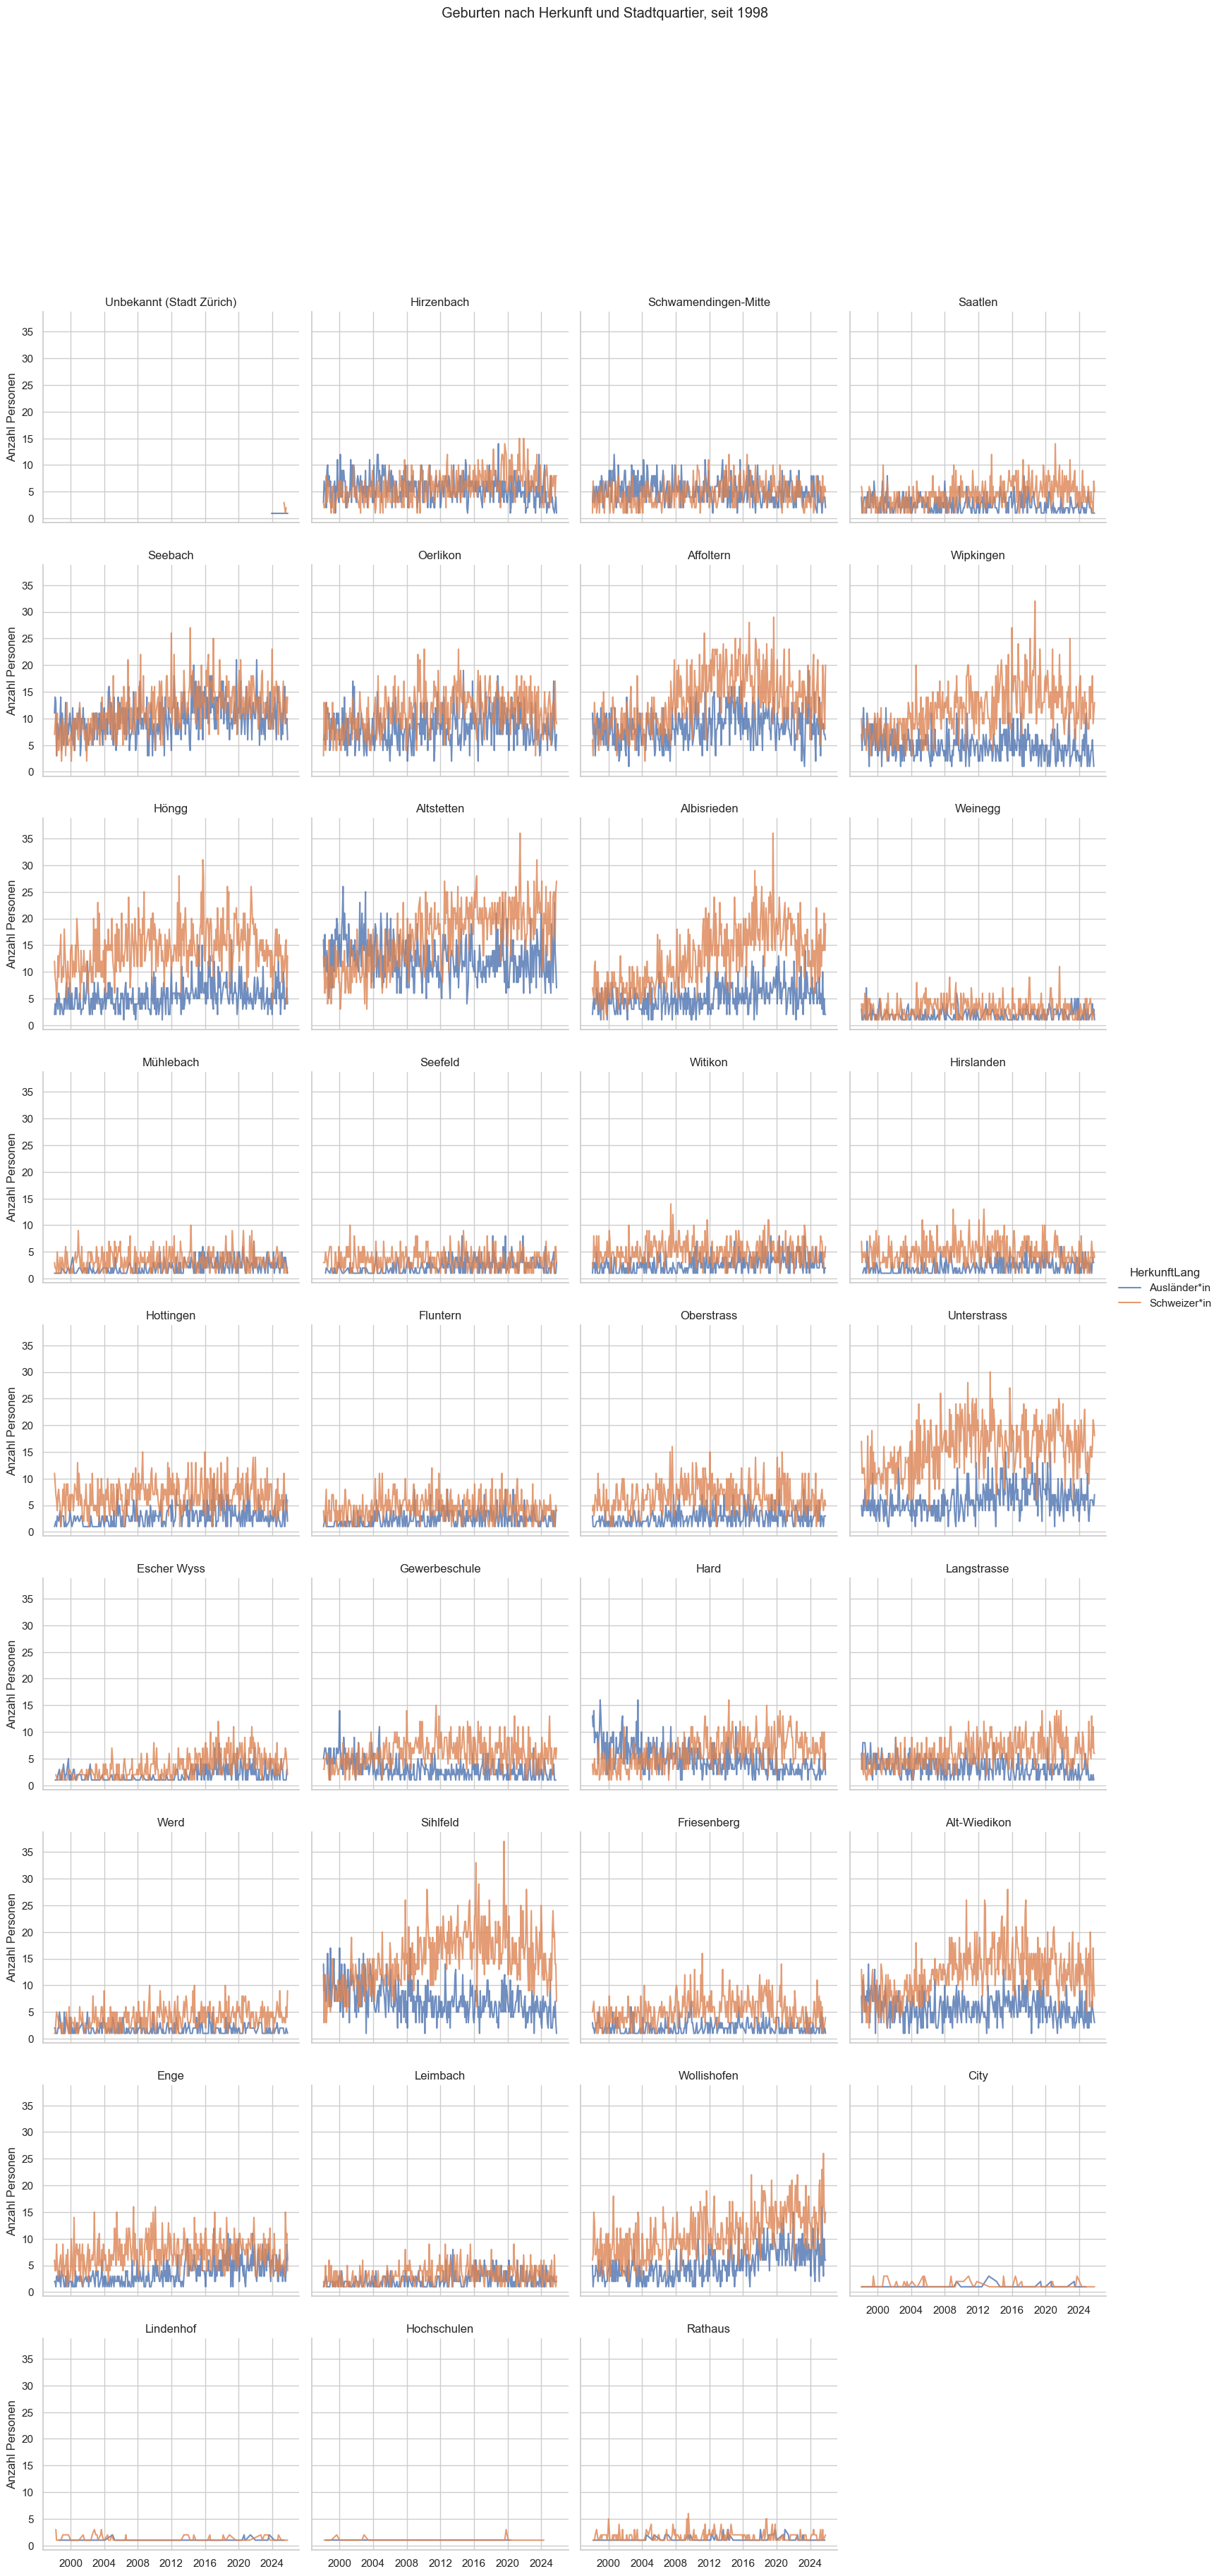

In [ ]:
faced_grid1 = mypy_dv.plot_sns_facetgrid(
    data = myFG.reset_index().sort_values('QuarCd', ascending=False)
    ,col = "QuarLang"
    ,hue = "HerkunftLang"
    ,col_wrap = 4
    ,grafiktyp = sns.lineplot
    ,x = "StichtagDat"
    ,y = "sum_WGeb"
    ,ylabel= "Anzahl Personen"
    ,warning_status ="ignore"
    ,height = 3
    ,myTitle="Geburten nach Herkunft und Stadtquartier, seit "+str(int(data2betested.index.year.min()))   
)

##### Gibt es zeitliche Datenlücken?

In [ ]:
#Gibt es eine zeitliche Datenlücke?

timefilter = "2025"
#lücke in der zeitreihe?
ideal_time_range = pd.date_range(start=data2betested.loc[timefilter].index.min(), end=data2betested.loc[timefilter].index.max(), freq='1m') #10h

# Überprüfe, ob es Unterschiede zwischen dem idealen Zeitstempelbereich und dem tatsächlichen Index gibt
missing_timestamps_my = ideal_time_range.difference(data2betested.index)

if missing_timestamps_my.empty:
    print("Keine Lücken in der Zeitreihe gefunden.")
else:
    print("Lücken in der Zeitreihe gefunden:")
    print(missing_timestamps_my)

Keine Lücken in der Zeitreihe gefunden.


### Daten in interaktiver Treemap zeigen
Dazu gibt es eine sehr nützliche Webseite https://plotly.com/python/treemaps/
Zu Farbskalen, siehe: https://plotly.com/python/builtin-colorscales/

**Funktion zum einfärben**

Muss ich noch als Funktion umsetzen 

In [ ]:
  qual12br = ["#5D4BFE", "#4AA9FF", "#55FFFF", "#986AD5", "#FC4C99", "#FF919A", "#349894", "#44B14A", "#B7E14E", "#B97624", "#FF7231", "#FFD736"]
  qual12 = ["#3431DE", "#0A8DF6", "#23C3F1", "#7B4FB7", "#DB247D", "#FB737E", "#007C78", "#1F9E31", "#99C32E", "#9A5B01", "#FF720C", "#FBB900"]
  qual12da = ["#0017BF", "#0072D7", "#00A5D2", "#5E359A", "#BA0062", "#DA5563", "#00615D", "#00770F", "#7BA600", "#7B4100", "#DC5500", "#DA9C00"]
  div9val = ["#782600", "#CC4309", "#FF720C", "#FFBC88", "#E4E0DF", "#AECBFF", "#6B8EFF", "#3B51FF", "#2F2ABB",]
  div9ntr = ["#A30059", "#DB247D", "#FF579E", "#FFA8D0", "#E4E0DF", "#A8DBB1", "#55BC5D", "#1F9E31", "#10652A",]

In [ ]:
# Extrahiere die Top-Fahrzeugmarken
color_var = data2betested['QuarLang'].unique().tolist()
# Verfügbare Farben
verfügbare_farben_zuericolors = qual12da+qual12br+qual12+div9ntr

# Erstelle das Farben-Dictionary
farben_dict_zc = {'(?)':'lightgrey'}
for index, x in enumerate(color_var):
    farben_dict_zc[x] = verfügbare_farben_zuericolors[index % len(verfügbare_farben_zuericolors)]

# Das resultierende Farben-Dictionary
print(farben_dict_zc)
#print(verfügbare_farben_zuericolors)

{'(?)': 'lightgrey', 'Wollishofen': '#0017BF', 'Seebach': '#0072D7', 'Oerlikon': '#00A5D2', 'Hirzenbach': '#5E359A', 'Alt-Wiedikon': '#BA0062', 'Friesenberg': '#DA5563', 'Sihlfeld': '#00615D', 'Werd': '#00770F', 'Langstrasse': '#7BA600', 'Hard': '#7B4100', 'Unterstrass': '#DC5500', 'Oberstrass': '#DA9C00', 'Fluntern': '#5D4BFE', 'Hottingen': '#4AA9FF', 'Hirslanden': '#55FFFF', 'Witikon': '#986AD5', 'Seefeld': '#FC4C99', 'Mühlebach': '#FF919A', 'Weinegg': '#349894', 'Albisrieden': '#44B14A', 'Altstetten': '#B7E14E', 'Höngg': '#B97624', 'Enge': '#FF7231', 'Wipkingen': '#FFD736', 'Schwamendingen-Mitte': '#3431DE', 'City': '#0A8DF6', 'Gewerbeschule': '#23C3F1', 'Saatlen': '#7B4FB7', 'Affoltern': '#DB247D', 'Leimbach': '#FB737E', 'Hochschulen': '#007C78', 'Rathaus': '#1F9E31', 'Escher Wyss': '#99C32E', 'Lindenhof': '#9A5B01', 'Unbekannt (Stadt Zürich)': '#FF720C'}


#### Geburten nach Stadtkreis, Quartier, Geschlecht und Herkunft

In [ ]:
myTreemapAgg = data2betested.loc["2020":data_max_date]   \
    .groupby(['StichtagDat','Jahr_nbr','KreisLang','QuarLang','HerkunftLang','SexLang' ]) \
    .agg(sum_WGeb=('AnzGebuWir', 'sum')) \
    .sort_values('StichtagDat', ascending=False) 

myTreemapAgg.reset_index().head(4)


,StichtagDat,Jahr_nbr,KreisLang,QuarLang,HerkunftLang,SexLang,sum_WGeb
0,2025-10-31,2025,Unbekannt (Stadt Zürich),Unbekannt (Stadt Zürich),Ausländer*in,weiblich,1
1,2025-10-31,2025,Kreis 2,Leimbach,Ausländer*in,weiblich,1
2,2025-10-31,2025,Kreis 12,Saatlen,Schweizer*in,männlich,2
3,2025-10-31,2025,Kreis 12,Saatlen,Schweizer*in,weiblich,3


In [ ]:
time_slot = data_max_date
print(time_slot)

2025-10-31


In [ ]:
treeMap1 = mypy_dv.plot_px_treemap(
    data=myTreemapAgg.loc[time_slot].reset_index()
    ,levels=['KreisLang','QuarLang','HerkunftLang','SexLang']
    ,values="sum_WGeb"
    ,color="QuarLang"
    #, color_continuous_scale='Blues'
    ,color_discrete_map=farben_dict_zc
    #,color_discrete_map={'(?)':'lightgrey', 'Erwerbstätige':'#99C32E', 'Nichterwerbspersonen':'#7B4100', 'Erwerbslose':'#DB247D'}  
    ,height=600
    ,width=1100               
    #,margin_val_bottom=25
    ,myHeaderTitle="Geburten nach Stadtkreis, Quartier, Herkunft und Geschlecht, "+time_slot

)
treeMap1

path: [<plotly.express._special_inputs.Constant object at 0x000002A89DE25D50>, 'KreisLang', 'QuarLang', 'HerkunftLang', 'SexLang']
Typ von path: <class 'list'>


Kreisen Farben zuweisen

In [ ]:
# Extrahiere die Top-Fahrzeugmarken
color_var = data2betested['KreisLang'].unique().tolist()
color_var = pd.Series(color_var).sort_values(ascending=False)
print(color_var)
# Verfügbare Farben
verfügbare_farben_zuericolors = div9ntr+qual12da+qual12br+qual12

# Erstelle das Farben-Dictionary
farben_dict_zc = {'(?)':'lightgrey'}
for index, x in enumerate(color_var):
    farben_dict_zc[x] = verfügbare_farben_zuericolors[index % len(verfügbare_farben_zuericolors)]

# Das resultierende Farben-Dictionary
print(farben_dict_zc)

12    Unbekannt (Stadt Zürich)
8                      Kreis 9
7                      Kreis 8
6                      Kreis 7
5                      Kreis 6
11                     Kreis 5
4                      Kreis 4
3                      Kreis 3
0                      Kreis 2
2                     Kreis 12
1                     Kreis 11
9                     Kreis 10
10                     Kreis 1
dtype: object
{'(?)': 'lightgrey', 'Unbekannt (Stadt Zürich)': '#A30059', 'Kreis 9': '#DB247D', 'Kreis 8': '#FF579E', 'Kreis 7': '#FFA8D0', 'Kreis 6': '#E4E0DF', 'Kreis 5': '#A8DBB1', 'Kreis 4': '#55BC5D', 'Kreis 3': '#1F9E31', 'Kreis 2': '#10652A', 'Kreis 12': '#0017BF', 'Kreis 11': '#0072D7', 'Kreis 10': '#00A5D2', 'Kreis 1': '#5E359A'}


In [ ]:
treeMap2 = mypy_dv.plot_px_treemap(
    data=myTreemapAgg.loc[time_slot].reset_index()
    ,levels=['HerkunftLang','SexLang','KreisLang','QuarLang']
    ,values="sum_WGeb"
    ,color="KreisLang"
    #, color_continuous_scale='Blues'
    ,color_discrete_map=farben_dict_zc
    #,color_discrete_map={'(?)':'lightgrey', 'Erwerbstätige':'#99C32E', 'Nichterwerbspersonen':'#7B4100', 'Erwerbslose':'#DB247D'}  
    ,height=600
    ,width=1100               
    #,margin_val_bottom=25
    ,myHeaderTitle="Geburten nach Stadtkreis, Quartier, Herkunft und Geschlecht, "+time_slot

)
treeMap2

path: [<plotly.express._special_inputs.Constant object at 0x000002A89A361210>, 'HerkunftLang', 'SexLang', 'KreisLang', 'QuarLang']
Typ von path: <class 'list'>


**Sharepoint als gecheckt markieren!**

Record auf Sharepoint: 

- **[Link](**[Link](http://kollaboration.intranet.stzh.ch/orga/ssz-produkte/Lists/SASA_Outputs/EditForm.aspx?ID=157&Source=%2Forga%2Fssz%2Dprodukte%2FLists%2FSASA%5FOutputs)**)**

- **[Früherer Link](http://kollaboration.intranet.stzh.ch/orga/ssz-produkte/Lists/SASA_Outputs/EditForm.aspx?ID=157&Source=%2Forga%2Fssz%2Dprodukte%2FLists%2FSASA%5FOutputs)**